# Real vs Fake Image Classification with a Simple CNN

This notebook trains a binary CNN classifier:
- `0` = real image (from `Data/images`)
- `1` = fake image (from synthetic diffusion outputs)

It first tries `Data/synthbuster` for generated images. If that is empty, it falls back to `Data/synthset_1k`.

In [1]:
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 8
LR = 1e-3

print(f"Using device: {DEVICE}")

Using device: cuda


d:\Coding\Programs\AI-ML\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_root = Path("Data")
real_root = data_root / "images"
synthbuster_root = data_root / "synthbuster"
synthset_root = data_root / "synthset_1k"

MODEL_NAMES = {
    "dalle2",
    "dalle3",
    "firefly",
    "glide",
    "midjourney-v5",
    "stable-diffusion-1-3",
    "stable-diffusion-1-4",
    "stable-diffusion-2",
    "stable-diffusion-xl",
}

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".webp"}


def is_image_file(path: Path) -> bool:
    return path.suffix.lower() in IMAGE_EXTENSIONS


def collect_images_recursive(root: Path):
    if not root.exists():
        return []
    return [p for p in root.rglob("*") if p.is_file() and is_image_file(p)]


real_paths = sorted(set(collect_images_recursive(real_root)))
fake_paths = sorted(set(collect_images_recursive(synthbuster_root)))
fake_source = "Data/synthbuster"

if len(fake_paths) == 0:
    fallback_candidates = collect_images_recursive(synthset_root)
    filtered_fake = []

    for p in fallback_candidates:
        parts = [part.lower() for part in p.parts]

        # Exclude any folder that explicitly marks real images.
        if "real" in parts or "0_real" in parts:
            continue

        if "1_fake" in parts or any(model_name in parts for model_name in MODEL_NAMES):
            filtered_fake.append(p)

    fake_paths = sorted(set(filtered_fake))
    fake_source = "Data/synthset_1k (fallback)"

print(f"Found {len(real_paths)} real images from: {real_root}")
print(f"Found {len(fake_paths)} fake images from: {fake_source}")

if len(real_paths) == 0:
    raise RuntimeError("No real images found in Data/images")
if len(fake_paths) == 0:
    raise RuntimeError("No fake images found in Data/synthbuster or Data/synthset_1k")

print("\nSample real images:")
for p in real_paths[:3]:
    print("  ", p)

print("\nSample fake images:")
for p in fake_paths[:3]:
    print("  ", p)

Found 999 real images from: Data\images
Found 8991 fake images from: Data/synthset_1k (fallback)

Sample real images:
   Data\images\r000da54ft.TIF
   Data\images\r001d260dt.TIF
   Data\images\r002fc3e2t.TIF

Sample fake images:
   Data\synthset_1k\test\dalle2\r00679daet.png
   Data\synthset_1k\test\dalle2\r01170470t.png
   Data\synthset_1k\test\dalle2\r01292fd8t.png


In [3]:
n_per_class = min(len(real_paths), len(fake_paths))

real_sample = random.sample(real_paths, n_per_class)
fake_sample = random.sample(fake_paths, n_per_class)

all_paths = real_sample + fake_sample
all_labels = [0] * n_per_class + [1] * n_per_class

X_train, X_temp, y_train, y_temp = train_test_split(
    all_paths,
    all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=SEED,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED,
)


def count_labels(labels):
    labels = np.array(labels)
    return {"real(0)": int((labels == 0).sum()), "fake(1)": int((labels == 1).sum())}


print(f"Balanced dataset size: {2 * n_per_class} images")
print("Train:", len(X_train), count_labels(y_train))
print("Val:  ", len(X_val), count_labels(y_val))
print("Test: ", len(X_test), count_labels(y_test))

Balanced dataset size: 1998 images
Train: 1398 {'real(0)': 699, 'fake(1)': 699}
Val:   300 {'real(0)': 150, 'fake(1)': 150}
Test:  300 {'real(0)': 150, 'fake(1)': 150}


In [4]:
class PathImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = float(self.labels[idx])

        with Image.open(img_path) as img:
            img = img.convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.float32)


train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_ds = PathImageDataset(X_train, y_train, transform=train_transform)
val_ds = PathImageDataset(X_val, y_val, transform=eval_transform)
test_ds = PathImageDataset(X_test, y_test, transform=eval_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 44
Val batches:   10
Test batches:  10


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        flattened_size = 128 * (IMAGE_SIZE[0] // 8) * (IMAGE_SIZE[1] // 8)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)


model = SimpleCNN().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)


In [6]:
def run_epoch(model, loader, criterion, optimizer=None, desc="train"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    progress = tqdm(loader, desc=desc, leave=False)

    for images, labels in progress:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                optimizer.step()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        running_loss += loss.item() * images.size(0)
        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    return epoch_loss, epoch_acc


history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = -1.0
best_state_dict = None

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.perf_counter()

    train_loss, train_acc = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        desc=f"Epoch {epoch}/{EPOCHS} train",
    )
    val_loss, val_acc = run_epoch(
        model,
        val_loader,
        criterion,
        desc=f"Epoch {epoch}/{EPOCHS} val",
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    elapsed = time.perf_counter() - epoch_start
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | "
        f"time={elapsed:.1f}s"
    )

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 01/8 | train_loss=0.6309, train_acc=0.6602 | val_loss=0.5753, val_acc=0.7433 | time=352.4s


Epoch 02/8 | train_loss=0.5488, train_acc=0.7325 | val_loss=0.4967, val_acc=0.7833 | time=369.2s


Epoch 03/8 | train_loss=0.5147, train_acc=0.7568 | val_loss=0.5408, val_acc=0.7767 | time=368.6s


Epoch 04/8 | train_loss=0.5166, train_acc=0.7682 | val_loss=0.4876, val_acc=0.7900 | time=369.4s


Epoch 05/8 | train_loss=0.4610, train_acc=0.7990 | val_loss=0.4530, val_acc=0.8033 | time=367.2s


Epoch 06/8 | train_loss=0.4371, train_acc=0.7969 | val_loss=0.4394, val_acc=0.8167 | time=367.6s


Epoch 07/8 | train_loss=0.3939, train_acc=0.8290 | val_loss=0.4856, val_acc=0.7967 | time=366.2s


Epoch 08/8 | train_loss=0.3956, train_acc=0.8219 | val_loss=0.4314, val_acc=0.7933 | time=366.4s

Best validation accuracy: 0.8167


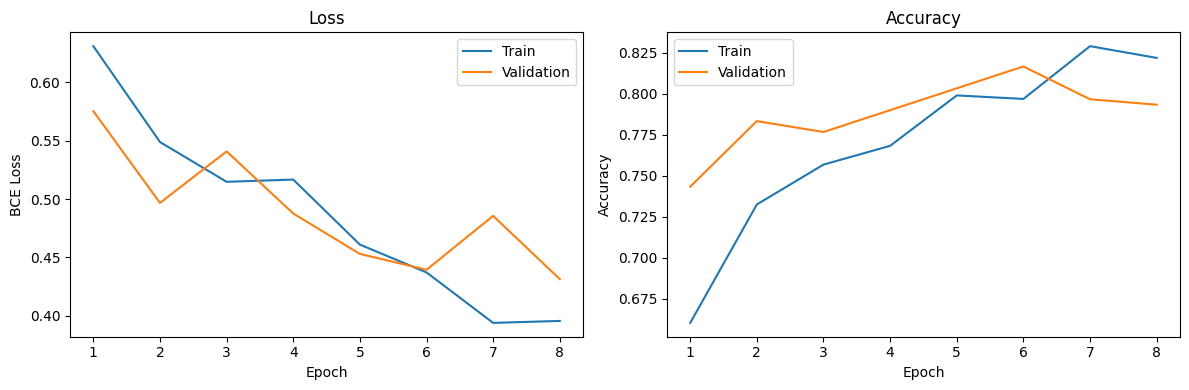

In [7]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"], label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

Test Metrics
Accuracy : 0.7833
Precision: 0.7742
Recall   : 0.8000
F1-score : 0.7869


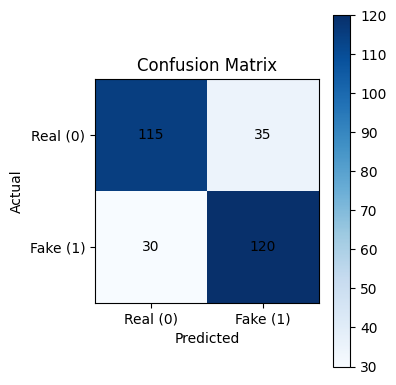

In [8]:
@torch.no_grad()
def predict_from_loader(model, loader):
    model.eval()
    all_probs = []
    all_targets = []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.extend(probs.tolist())
        all_targets.extend(labels.numpy().tolist())

    return np.array(all_targets), np.array(all_probs)


y_true, y_prob = predict_from_loader(model, test_loader)
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="binary",
    zero_division=0,
)

print("Test Metrics")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Real (0)", "Fake (1)"])
ax.set_yticklabels(["Real (0)", "Fake (1)"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im)
plt.tight_layout()
plt.show()

Sample image: Data\synthset_1k\train\stable-diffusion-1-4\1_fake\r09670876t.png
Predicted class: Fake (1)
Fake probability: 0.8339


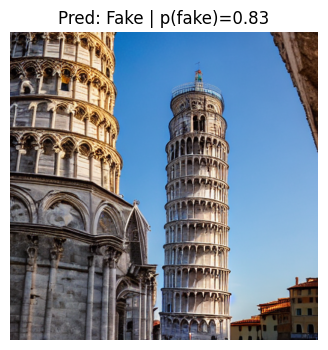

In [9]:
@torch.no_grad()
def predict_single_image(image_path, model, transform):
    image_path = Path(image_path)

    with Image.open(image_path) as img:
        rgb_img = img.convert("RGB")

    x = transform(rgb_img).unsqueeze(0).to(DEVICE)
    logit = model(x)
    prob_fake = torch.sigmoid(logit).item()
    pred_label = 1 if prob_fake >= 0.5 else 0

    return pred_label, prob_fake


sample_image = X_test[0]
pred_label, prob_fake = predict_single_image(sample_image, model, eval_transform)

print(f"Sample image: {sample_image}")
print(f"Predicted class: {'Fake (1)' if pred_label == 1 else 'Real (0)'}")
print(f"Fake probability: {prob_fake:.4f}")

with Image.open(sample_image) as img:
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Pred: {'Fake' if pred_label == 1 else 'Real'} | p(fake)={prob_fake:.2f}")
    plt.show()

Sample image: Data/myimg/1.jpeg
Predicted class: Fake (1)
Fake probability: 0.6611


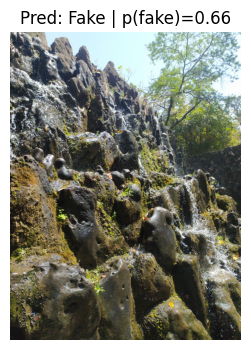

In [11]:
sample_image = "Data/myimg/1.jpeg"
pred_label, prob_fake = predict_single_image(sample_image, model, eval_transform)

print(f"Sample image: {sample_image}")
print(f"Predicted class: {'Fake (1)' if pred_label == 1 else 'Real (0)'}")
print(f"Fake probability: {prob_fake:.4f}")

with Image.open(sample_image) as img:
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Pred: {'Fake' if pred_label == 1 else 'Real'} | p(fake)={prob_fake:.2f}")
    plt.show()